11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


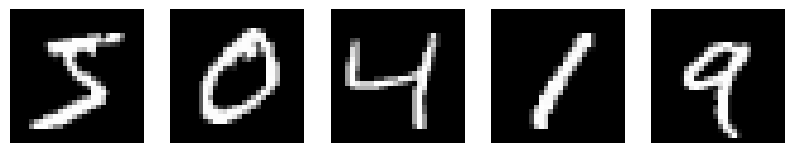

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9763 - loss: 0.0936
Test Accuracy: 0.98
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


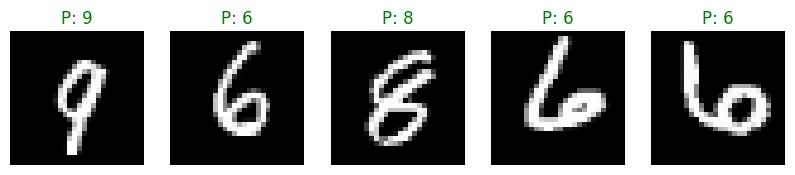

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
y_train, y_test = to_categorical(y_train, 10), to_categorical(y_test, 10)
fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i, ax in enumerate(axes):
 ax.imshow(x_train[i], cmap='gray')
 ax.axis('off')
plt.show()
model = Sequential([
 Flatten(input_shape=(28, 28)),
 Dense(128, activation='relu'),
 Dense(64, activation='relu'),
 Dense(10, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy',
metrics=['accuracy'])
history = model.fit(x_train, y_train, epochs=10, validation_split=0.2,
verbose=0)
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_acc:.2f}")
sample_idx = np.random.choice(len(x_test), 5, replace=False)
x_sample, y_sample = x_test[sample_idx], y_test[sample_idx]
predictions = model.predict(x_sample)
fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i, ax in enumerate(axes):
 ax.imshow(x_sample[i], cmap='gray')
 ax.axis('off')
 ax.set_title(f"P: {np.argmax(predictions[i])}", color='green')
plt.show()


In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

model_id = 'ibm-granite/granite-3.1-2b-instruct'
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
 model_id,
 torch_dtype=torch.float16,
 device_map='auto'
)

messages = [
 {'role': 'user',
 'content': 'Explain what a transformer is in 3 bullet points for a student.'}
]

input_ids = tokenizer.apply_chat_template(messages, return_tensors='pt')['input_ids'].to(model.device)
output = model.generate(
 input_ids,
 max_new_tokens=256,
 temperature=0.7,
 do_sample=True
)

response = tokenizer.decode(output[0][input_ids.shape[1]:], skip_special_tokens=True)
print(response)


config.json:   0%|          | 0.00/786 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.48M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/87.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/701 [00:00<?, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/362 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.



- A transformer is a type of artificial neural network architecture, specifically designed for handling sequential data like text, speech, and time series. It was introduced in the groundbreaking 2017 paper "Attention is All You Need" by Vaswani et al.

- Unlike traditional recurrent neural networks (RNNs), transformers process all input elements simultaneously, which significantly reduces the computational complexity and enables faster training times. This is achieved through a mechanism called "self-attention" or "scaled dot-product attention," where the model can weigh the importance of various parts of the input sequence when generating an output.

- Transformers have revolutionized natural language processing (NLP) tasks, such as machine translation, text summarization, and sentiment analysis, by providing state-of-the-art performance. They have also inspired the development of other transformer-based models like BERT (Bidirectional Encoder Representations from Transformers), RoB